In [3]:
import os
import sys
import time
import copy

import numpy as np
import math
import random
import matplotlib.pyplot as plt

import functools
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils

import pickle

import datasets, models
import importlib
importlib.reload(models)
import init, measures
importlib.reload(init)
importlib.reload(measures)

<module 'measures' from '/Users/julialand/Desktop/SISSA/RLM/RLM_clean/measures.py'>

In [4]:
from dataclasses import dataclass
@dataclass
class config:

    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers # context length, tuple_size**num_layers for the full input
    beta = 2

    train_size = 2**16 #reduce by 9
    batch_size = 128
    accumulation = 1
    test_size = 2**15 #reduce by 6
    seed_sample = 56781234

    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    embedding_dim = 64
    num_heads = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678

    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = False
    loss_threshold = 1e-3
config.num_data = config.train_size + config.test_size
#config.num_data = config.num_classes*config.num_synonyms**((config.tuple_size**config.num_layers-1)//(config.tuple_size-1))
config.input_size = 2**config.num_layers
config.num_batches = config.train_size//config.batch_size
config.max_iters = config.max_epochs*config.num_batches

print(config.device)

print(f"Training for {config.max_iters} steps")

mps
Training for 5120 steps


In [5]:
# reinitialise dataset seeds for multiple runs
config.seed_rules = random.randint(10000000,99999999)
config.seed_sample = random.randint(10000000,99999999)
print(config.seed_rules, config.seed_sample)

70989005 28738663


In [6]:
if config.dataset=='rlm':

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.train_size+config.test_size,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]
    entropy = rlm.entropy

print(inputs.size())
print(targets.size())
train_loader, test_loader = init.init_data(inputs, targets, config)


torch.Size([98304, 2])
torch.Size([98304])


In [27]:
config.num_tokens = 2**config.num_layers
config.seed_model = random.randint(10000000,99999999)

model = init.init_model(config)
model0 = copy.deepcopy( model)

# parameters: 57984


In [28]:
criterion, optimizer, scheduler = init.init_training( model, config)

In [29]:
%%time
dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)
print(dynamics[0])
# print(best)

print_ckpts, save_ckpts = init.init_loglinckpt( config.print_freq, config.max_iters, freq=config.save_freq)
print_ckpt = next(print_ckpts)
save_ckpt = next(save_ckpts)

step = 0
config.outname = f'rlm_L2_v{config.num_features}_beta{config.beta}_mlm_d{config.depth}_ed{config.embedding_dim}_nh{config.num_heads}_{config.seed_rules}'
print(config.outname)

{'t': 0, 'testloss': 4.324745133519173, 'testacc': 0.0101318359375}
rlm_L2_v64_beta2_mlm_d1_ed64_nh1_30752826
CPU times: user 110 ms, sys: 49.9 ms, total: 160 ms
Wall time: 251 ms


In [30]:
print(save_ckpts)

In [31]:
for epoch in range(config.max_epochs):

    model.train()
    optimizer.zero_grad()
    running_loss = 0.

    for batch_idx, (inputs, targets) in enumerate(train_loader):

        outputs = model(inputs.to(config.device))
        loss = criterion(outputs, targets.to(config.device))
        running_loss += loss.item()
        loss /= config.accumulation
        loss.backward()

        if ((batch_idx+1)%config.accumulation==0):
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
            step += 1

            if step==print_ckpt:

                test_loss, test_acc = measures.test(model, criterion, test_loader, config.device)

                if test_loss<best['loss']: # update best model if loss is smaller
                    best['step'] = step
                    best['loss'] = test_loss
                    best['model'] = copy.deepcopy( model.state_dict())

                print('step : ',step, '\t running loss: {:06.4f}'.format(running_loss/(batch_idx+1)), ', test loss: {:06.4f}'.format(test_loss))
                print_ckpt = next(print_ckpts)

                if step>=save_ckpt:

                    print(f'Checkpoint at step {step}, saving data ...')
                    save_dict = {'t': step, 'testloss': test_loss, 'testacc': test_acc}
                    if config.measure_train:
                        train_loss, train_acc = measures.test(model, criterion, train_loader, config.device)
                        save_dict['trainloss'] = train_loss
                        save_dict['trainacc'] = train_acc
                    dynamics.append(save_dict)

                    output = {
                        'rules': rlm.M,
                        'init': model0.state_dict(),
                        'best': best,
                        'model': copy.deepcopy(model.state_dict()),
                        'dynamics': dynamics,
                        'step': step
                    }
                    with open(config.outname, "wb") as handle:
                        pickle.dump(config, handle)
                        pickle.dump(output, handle)

                    save_ckpt = next(save_ckpts)


    if (running_loss/(batch_idx+1)) <= config.loss_threshold:

        save_dict = {'t': step, 'testloss': test_loss, 'testacc': test_acc}
        if config.measure_train:
            train_loss, train_acc = measures.test(model, criterion, train_loader, config.device)
            save_dict['trainloss'] = train_loss
            save_dict['trainacc'] = train_acc
        dynamics.append(save_dict)

        output = {
            'rules': rlm.M,
            'init': model0.state_dict(),
            'best': best,
            'model': copy.deepcopy(model.state_dict()),
            'dynamics': dynamics,
            'step': step
        }
        with open(config.outname, "wb") as handle:
            pickle.dump(config, handle)
            pickle.dump(output, handle)

        break

step :  1 	 running loss: 4.3372 , test loss: 4.3247
Checkpoint at step 1, saving data ...
step :  2 	 running loss: 4.3592 , test loss: 4.3212
Checkpoint at step 2, saving data ...
step :  3 	 running loss: 4.3483 , test loss: 4.3142
Checkpoint at step 3, saving data ...
step :  4 	 running loss: 4.3467 , test loss: 4.3037
Checkpoint at step 4, saving data ...
step :  6 	 running loss: 4.3285 , test loss: 4.2741
Checkpoint at step 6, saving data ...
step :  8 	 running loss: 4.3169 , test loss: 4.2366
Checkpoint at step 8, saving data ...
step :  11 	 running loss: 4.2974 , test loss: 4.1783
Checkpoint at step 11, saving data ...
step :  16 	 running loss: 4.2535 , test loss: 4.1104
Checkpoint at step 16, saving data ...
step :  23 	 running loss: 4.1967 , test loss: 4.0613
Checkpoint at step 23, saving data ...
step :  32 	 running loss: 4.1614 , test loss: 4.0388
Checkpoint at step 32, saving data ...
step :  45 	 running loss: 4.1200 , test loss: 4.0094
Checkpoint at step 45, savin

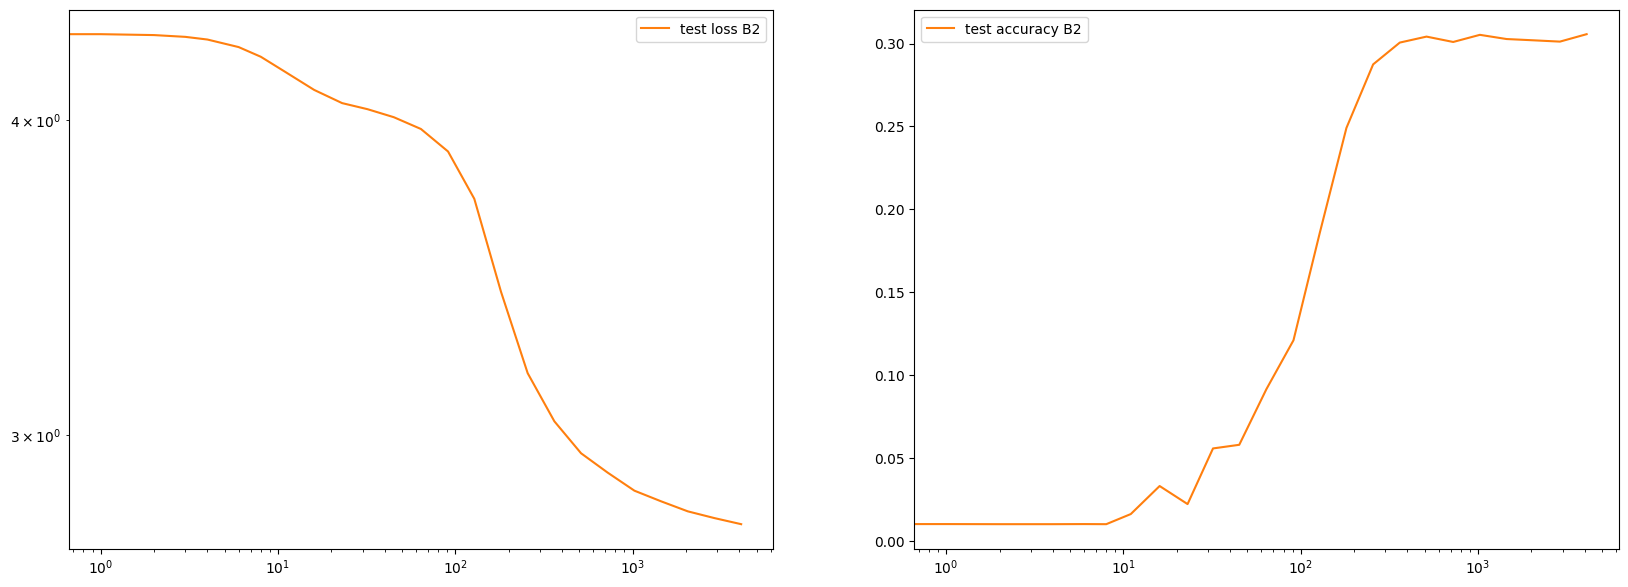

In [32]:
import math

fig, ax = plt.subplots(1, 2, figsize=(20,7))

ax[0].plot([d['t'] for d in dynamics], [d['testloss'] for d in dynamics], f'C1', label='test loss B' + str(config.beta))
ax[1].plot([d['t'] for d in dynamics], [d['testacc'] for d in dynamics], f'C1', label='test accuracy B' + str(config.beta))

if config.measure_train:
    ax[0].plot([d['t'] for d in dynamics], [d['trainloss'] for d in dynamics], f'C0', label='training loss')
    ax[1].plot([d['t'] for d in dynamics], [d['trainacc'] for d in dynamics], f'C0', label='training accuracy')


L = config.num_layers
v = config.num_features



ax[0].legend()
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].legend()
ax[1].set_xscale('log')

## End

# Diference theorical - Experimental

In [17]:
prior = labels = torch.randint(config.num_features, (config.num_features,))

In [18]:
print(f"For beta: {config.beta} & for Vocabulary: {config.num_features}")
print(f"Theoretical: {init.measures.conditional_entropy_from_joint(init.measures.joint_children(rlm.M, prior)).item()}")
print(f"Experimental: {test_loss}")
print(f"Difference: {init.measures.conditional_entropy_from_joint(init.measures.joint_children(rlm.M, prior)).item() - test_loss}")

For beta: 2 & for Vocabulary: 64
Theoretical: 2.329375076990419
Experimental: 2.6042440608143806
Difference: -0.2748689838239615


In [ ]:
dynamics

[{'t': 0, 'testloss': 2.8696059957146645, 'testacc': 0.073089599609375},
 {'t': 1, 'testloss': 2.8696059957146645, 'testacc': 0.073089599609375},
 {'t': 2, 'testloss': 2.8419631123542786, 'testacc': 0.12384033203125},
 {'t': 3, 'testloss': 2.7973269298672676, 'testacc': 0.094024658203125},
 {'t': 4, 'testloss': 2.746412567794323, 'testacc': 0.09259033203125},
 {'t': 6, 'testloss': 2.6839815378189087, 'testacc': 0.13714599609375},
 {'t': 8, 'testloss': 2.727753557264805, 'testacc': 0.1387939453125},
 {'t': 11, 'testloss': 2.7027404382824898, 'testacc': 0.1387939453125},
 {'t': 16, 'testloss': 2.5071496814489365, 'testacc': 0.27655029296875},
 {'t': 23, 'testloss': 2.263911508023739, 'testacc': 0.3211669921875},
 {'t': 32, 'testloss': 2.115704983472824, 'testacc': 0.35107421875},
 {'t': 45, 'testloss': 2.0049512535333633, 'testacc': 0.36944580078125},
 {'t': 64, 'testloss': 1.9687465727329254, 'testacc': 0.33929443359375},
 {'t': 91, 'testloss': 1.9405122995376587, 'testacc': 0.356964111

In [ ]:
prior = labels = torch.randint(config.num_features, (config.num_features,))
init.measures.conditional_entropy(rlm.M,)

tensor(2.3758, dtype=torch.float64)

In [ ]:
def conditional_entropy(M: torch.Tensor,V, num_data,prior=None,device=None, generator=None):
    if prior is None:
        labels = torch.randint(config.num_features, (config.num_features,))
    else:
        p0 = prior.to(device=device, dtype=M.dtype)
        p0 = p0 / p0.sum()
        labels = torch.multinomial(p0, num_data, replacement=True, generator=generator)
    prior = prior / prior.sum()
    Pxy = torch.einsum('n,nab->ab', prior, M)
    Pxy = Pxy / Pxy.sum()
    Px = Pxy.sum(dim=1)
    return entropy(Pxy) - entropy(Px)

In [19]:
init.measures.conditional_entropy(rlm.M,config.num_features,config.num_data)

tensor(2.5298, dtype=torch.float64)